# Astronomical Object EDA
**Dataset:** 10,000 spectroscopically confirmed observations (STAR, GALAXY, QSO)  
**Goal:** Clean the data, engineer photometric colour features, and prepare a dataset for unsupervised clustering.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

## 1. Load Dataset

In [2]:
df = pd.read_csv('../Model & Dataset/star-galaxy-quasar.csv', skiprows=1)
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (10000, 10)
Columns: ['objid', 'ra', 'dec', 'u', 'g', 'r', 'i', 'z', 'class', 'redshift']


,objid,ra,dec,u,g,r,i,z,class,redshift
0,1237654669735231608,149.142428,-0.372420,19.76743,17.87560,16.90248,16.45606,16.12213,GALAXY,0.091934
1,1237651801233686770,149.117936,0.183976,18.20582,16.46298,15.49704,14.95910,14.60985,GALAXY,0.065808
2,1237651800696881217,149.156198,-0.315231,19.78793,18.33921,17.48833,17.07277,16.74467,GALAXY,0.085327
3,1237654670272102476,149.128104,0.083621,20.33225,18.35458,17.40644,16.95075,16.59546,GALAXY,0.088111
4,1237651801233752148,149.153997,0.172473,19.67747,18.19364,17.51096,17.09774,16.89891,GALAXY,0.079039


## 2. Drop RA and Dec

Right ascension (`ra`) and declination (`dec`) are sky coordinates — they describe *where* an object is, not *what* it is. All three classes (STAR, GALAXY, QSO) are distributed across the sky with no systematic spatial segregation at survey scale. Including these columns would inject positional noise into distance-based clustering without contributing discriminative signal.

In [3]:
df = df.drop(columns=['ra', 'dec'])
print(f'Shape after dropping coordinates: {df.shape}')

Shape after dropping coordinates: (10000, 8)


## 3. Remove Outliers

Two filtering rules are applied:
- **Band magnitudes** (u, g, r, i, z): must be strictly between -50 and 50. Values outside this range indicate sensor saturation or pipeline errors and are not physically meaningful (Richards et al. 2002, SDSS photometric survey).
- **Redshift**: must be strictly greater than 0. Negative or zero redshifts are non-physical for extragalactic objects, and `redshift > 0` is required for the log transform applied in step 8.

In [4]:
bands = ['u', 'g', 'r', 'i', 'z']
for band in bands:
    df = df[(df[band] > -50) & (df[band] < 50)]

df = df[df['redshift'] > 0]

print(f'Shape after removing outliers: {df.shape}')
print(f'NaN counts:\n{df.isnull().sum()}')

Shape after removing outliers: (9733, 8)
NaN counts:
objid       0
u           0
g           0
r           0
i           0
z           0
class       0
redshift    0
dtype: int64


## 4. Create Colour Band Differences

Raw band magnitudes (u, g, r, i, z) encode both the intrinsic spectral energy distribution (SED) of an object *and* its distance, which shifts apparent brightness uniformly across all bands. Colour indices — differences between adjacent or non-adjacent bands — cancel the distance-dependent component and isolate the SED shape, which is the physically meaningful discriminant between object types (Fukugita et al. 1996; Richards et al. 2001).

Six colour indices are computed:

| Feature | Physical meaning |
|---|---|
| `u-g` | UV excess; hot stars and quasars show very negative u-g relative to galaxies (Richards et al. 2002) |
| `g-r` | Primary optical colour; separates the stellar locus from the galaxy locus and tracks galaxy age (Strateva et al. 2001) |
| `r-i` | Near-IR transition; less sensitive to dust reddening than g-r; breaks colour degeneracies (Fukugita et al. 1996) |
| `i-z` | Far near-IR colour; distinguishes cool stars and high-z galaxies; least dust-affected band pair (York et al. 2000) |

In [5]:
df['u-g'] = df['u'] - df['g']
df['g-r'] = df['g'] - df['r']
df['r-i'] = df['r'] - df['i']
df['i-z'] = df['i'] - df['z']

print('Colour band differences created.')
df[['u-g', 'g-r', 'r-i', 'i-z']].describe()

Colour band differences created.


,u-g,g-r,r-i,i-z
count,9733.000000,9733.000000,9733.000000,9733.000000
mean,1.633288,0.874502,0.407775,0.281662
std,0.738476,0.475846,0.272237,0.252130
min,-8.235660,-6.683520,-12.963090,-5.649330
25%,1.226410,0.595670,0.351250,0.214390
50%,1.681190,0.881820,0.424550,0.317010
75%,1.971460,1.053450,0.477970,0.364590
max,8.175870,8.396770,7.161740,11.546050


## 5. Correlation Heatmap

We inspect pairwise correlations across both the raw band magnitudes and the derived colour indices to understand the redundancy structure of the feature space.

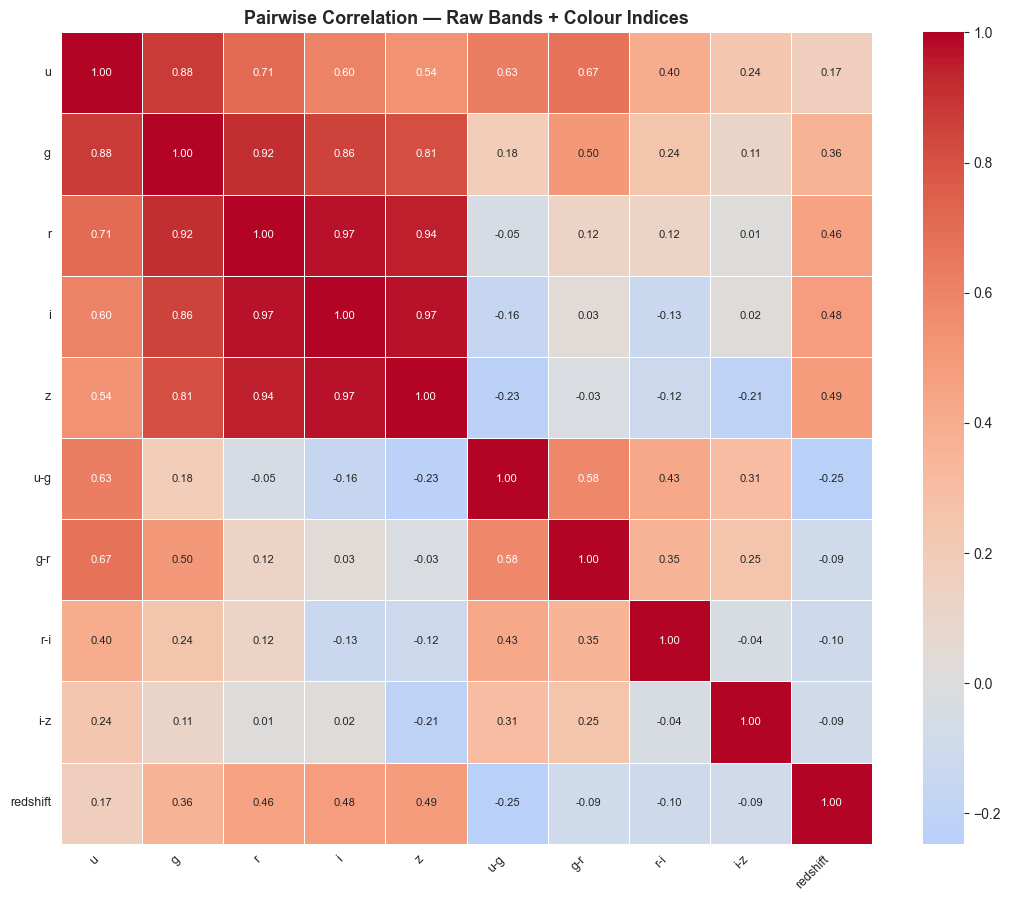

In [6]:
feature_cols = ['u', 'g', 'r', 'i', 'z', 'u-g', 'g-r', 'r-i', 'i-z', 'redshift']
corr = df[feature_cols].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
    square=True, linewidths=0.4, annot_kws={'fontsize': 8}
)
plt.title('Pairwise Correlation — Raw Bands + Colour Indices', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

## 6. Drop Raw Band Magnitudes

The heatmap confirms that the raw band magnitudes (u, g, r, i, z) are **highly correlated with one another** (|r| > 0.90 for most pairs). This multicollinearity reflects the fact that each band tracks the same underlying brightness, shifted by a near-constant offset across object types.

The colour indices already encode the *differential* SED information between bands — the discriminative signal for object classification. Retaining the raw magnitudes alongside the colour indices would double-count this information, inflate dimensionality, and bias distance-based clustering algorithms toward whichever features happen to have the largest absolute scale.

The raw bands are therefore dropped.

In [7]:
df = df.drop(columns=['u', 'g', 'r', 'i', 'z'])
print(f'Shape after dropping raw bands: {df.shape}')
print(f'Remaining columns: {list(df.columns)}')

Shape after dropping raw bands: (9733, 7)
Remaining columns: ['objid', 'class', 'redshift', 'u-g', 'g-r', 'r-i', 'i-z']


## 7. Redshift Distribution

Before transforming redshift, we examine its distribution to understand its skew and dynamic range across the three object classes.

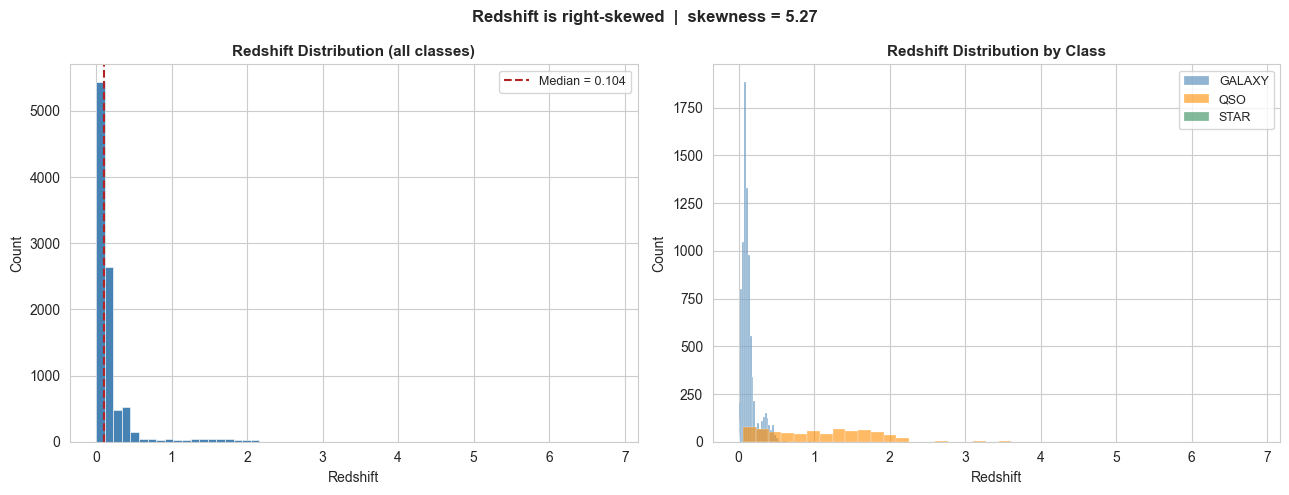

count    9.733000e+03
mean     1.940722e-01
std      3.343848e-01
min      4.305946e-07
25%      7.126261e-02
50%      1.037074e-01
75%      1.630619e-01
max      6.827977e+00
Name: redshift, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df['redshift'], bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_title('Redshift Distribution (all classes)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Redshift', fontsize=10)
axes[0].set_ylabel('Count', fontsize=10)
axes[0].axvline(
    df['redshift'].median(), color='firebrick', linestyle='--',
    label=f"Median = {df['redshift'].median():.3f}"
)
axes[0].legend(fontsize=9)

for cls, color in [('GALAXY', 'steelblue'), ('QSO', 'darkorange'), ('STAR', 'seagreen')]:
    subset = df[df['class'] == cls]['redshift']
    axes[1].hist(subset, bins=40, alpha=0.6, label=cls, color=color, edgecolor='white', linewidth=0.3)
axes[1].set_title('Redshift Distribution by Class', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Redshift', fontsize=10)
axes[1].set_ylabel('Count', fontsize=10)
axes[1].legend(fontsize=9)

plt.suptitle(
    f'Redshift is right-skewed  |  skewness = {df["redshift"].skew():.2f}',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

print(df['redshift'].describe())

## 8. Log Transform Redshift

The redshift distribution is strongly right-skewed, with the majority of objects at low redshift and a long tail extending to high values driven by QSOs. This skew distorts Euclidean distance calculations in clustering — a QSO at z = 2 appears disproportionately distant from a QSO at z = 0.5, even though both are quasars and occupy the same class.

A log10 transform compresses the dynamic range and produces a more symmetric distribution, making redshift comparable in scale to the colour indices. Since `redshift > 0` was enforced during outlier removal, the log is well-defined for all remaining rows.

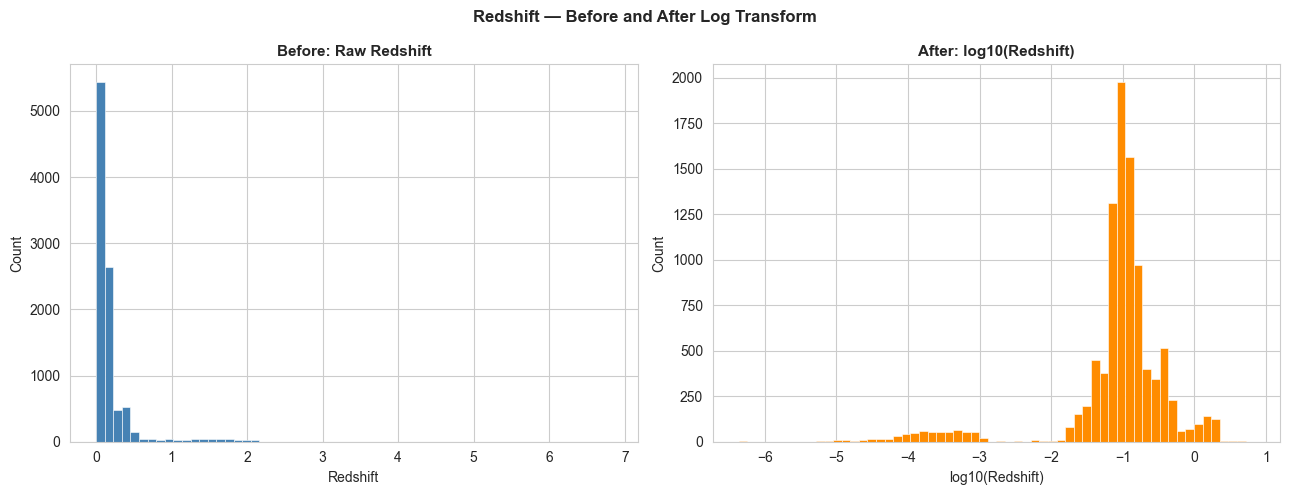

Skewness before: 5.2705
Skewness after:  -2.3969

Final columns: ['objid', 'class', 'u-g', 'g-r', 'r-i', 'i-z', 'redshift_log']


In [9]:
df['redshift_log'] = np.log10(df['redshift'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df['redshift'], bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_title('Before: Raw Redshift', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Redshift', fontsize=10)
axes[0].set_ylabel('Count', fontsize=10)

axes[1].hist(df['redshift_log'], bins=60, color='darkorange', edgecolor='white', linewidth=0.4)
axes[1].set_title('After: log10(Redshift)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('log10(Redshift)', fontsize=10)
axes[1].set_ylabel('Count', fontsize=10)

plt.suptitle('Redshift — Before and After Log Transform', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Skewness before: {df["redshift"].skew():.4f}')
print(f'Skewness after:  {df["redshift_log"].skew():.4f}')

df = df.drop(columns=['redshift'])
print(f'\nFinal columns: {list(df.columns)}')

## 9. Feature Distribution Analysis

Before saving and scaling the data, we analyse the distribution of each final feature to determine the most appropriate scaler. The key properties to examine are:
- **Skewness** — asymmetry of the distribution
- **Kurtosis** — heaviness of tails relative to a Gaussian
- **Outliers** — presence of extreme values that could distort distance-based scalers
- **Modality** — whether the distribution is unimodal or multi-modal (driven by class mixing)

In [10]:
from scipy import stats

feat_cols = ['u-g', 'g-r', 'r-i', 'i-z', 'redshift_log']

# Skewness, kurtosis, and percentile-based outlier stats
rows = []
for col in feat_cols:
    s = df[col]
    iqr = s.quantile(0.75) - s.quantile(0.25)
    outlier_pct = ((s < s.quantile(0.25) - 1.5*iqr) | (s > s.quantile(0.75) + 1.5*iqr)).mean() * 100
    _, p_normal = stats.normaltest(s)
    rows.append({
        'feature':     col,
        'mean':        s.mean(),
        'std':         s.std(),
        'skewness':    s.skew(),
        'kurtosis':    s.kurtosis(),
        'outlier_%':   outlier_pct,
        'normal_p':    p_normal
    })

stats_df = pd.DataFrame(rows).set_index('feature')
stats_df = stats_df.round(4)
print('Feature statistics:')
stats_df

Feature statistics:


,mean,std,skewness,kurtosis,outlier_%,normal_p
feature,,,,,,
u-g,1.6333,0.7385,0.9806,11.5303,4.1919,0.0
g-r,0.8745,0.4758,0.7751,33.0099,5.8255,0.0
r-i,0.4078,0.2722,-13.2180,715.2681,12.3292,0.0
i-z,0.2817,0.2521,12.4565,672.7720,4.7262,0.0
redshift_log,-1.0836,0.7883,-2.3969,7.4127,12.7710,0.0


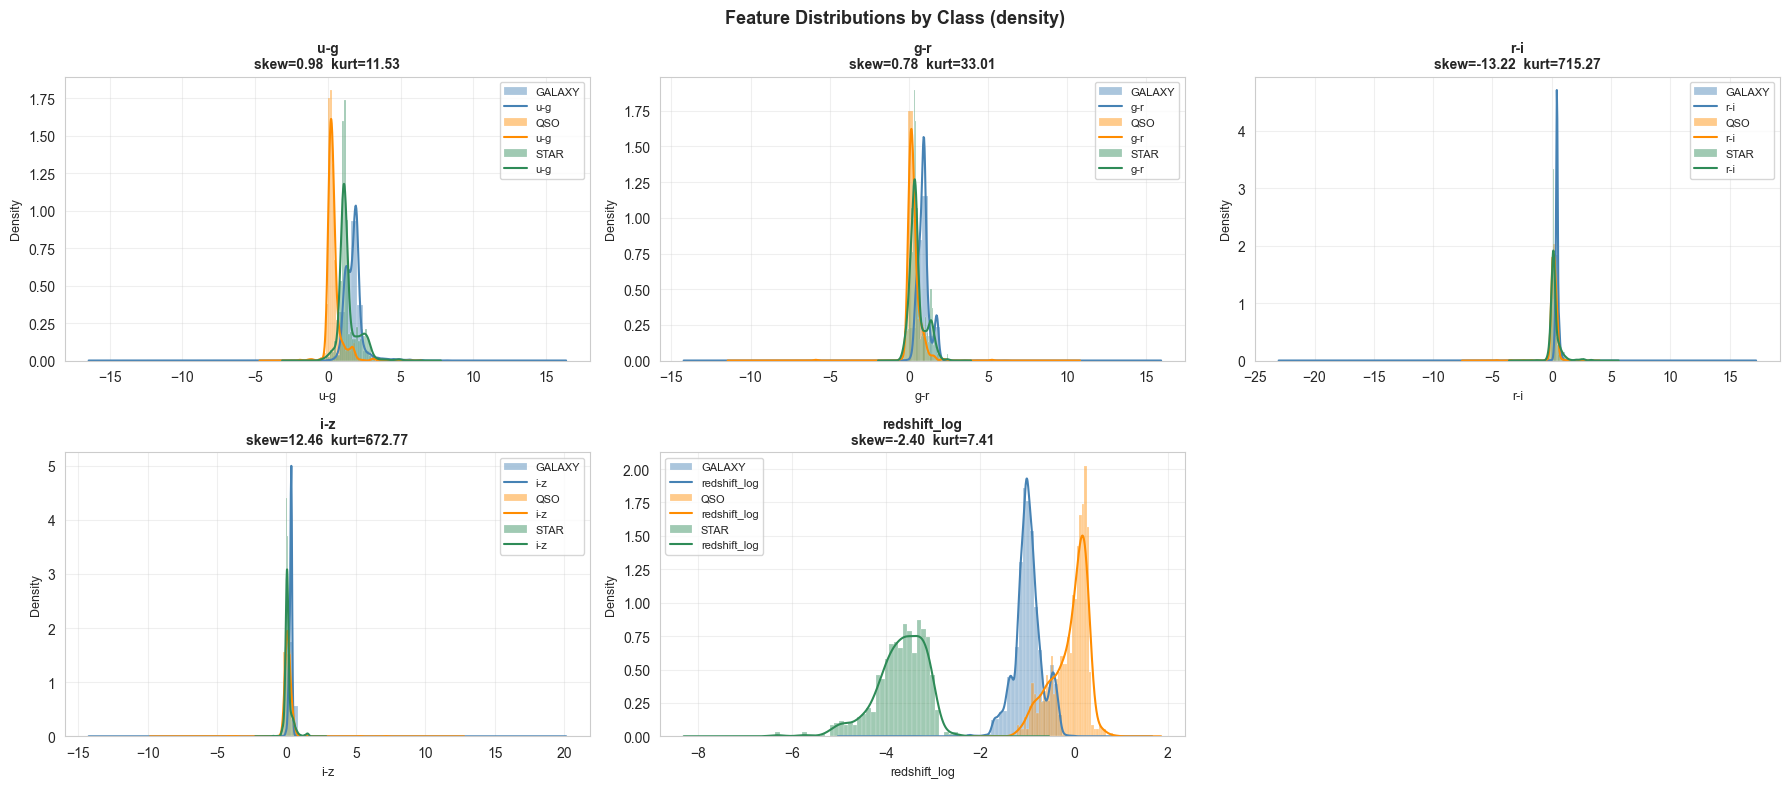

In [11]:
# Histograms + KDE per feature, split by class
colors = {'GALAXY': 'steelblue', 'QSO': 'darkorange', 'STAR': 'seagreen'}

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(feat_cols):
    ax = axes[i]
    for cls, color in colors.items():
        subset = df[df['class'] == cls][col]
        ax.hist(subset, bins=40, alpha=0.45, color=color, density=True,
                label=cls, edgecolor='white', linewidth=0.3)
        subset.plot.kde(ax=ax, color=color, linewidth=1.5)
    ax.set_title(
        f'{col}\nskew={df[col].skew():.2f}  kurt={df[col].kurtosis():.2f}',
        fontsize=10, fontweight='bold'
    )
    ax.set_xlabel(col, fontsize=9)
    ax.set_ylabel('Density', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_visible(False)
plt.suptitle('Feature Distributions by Class (density)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

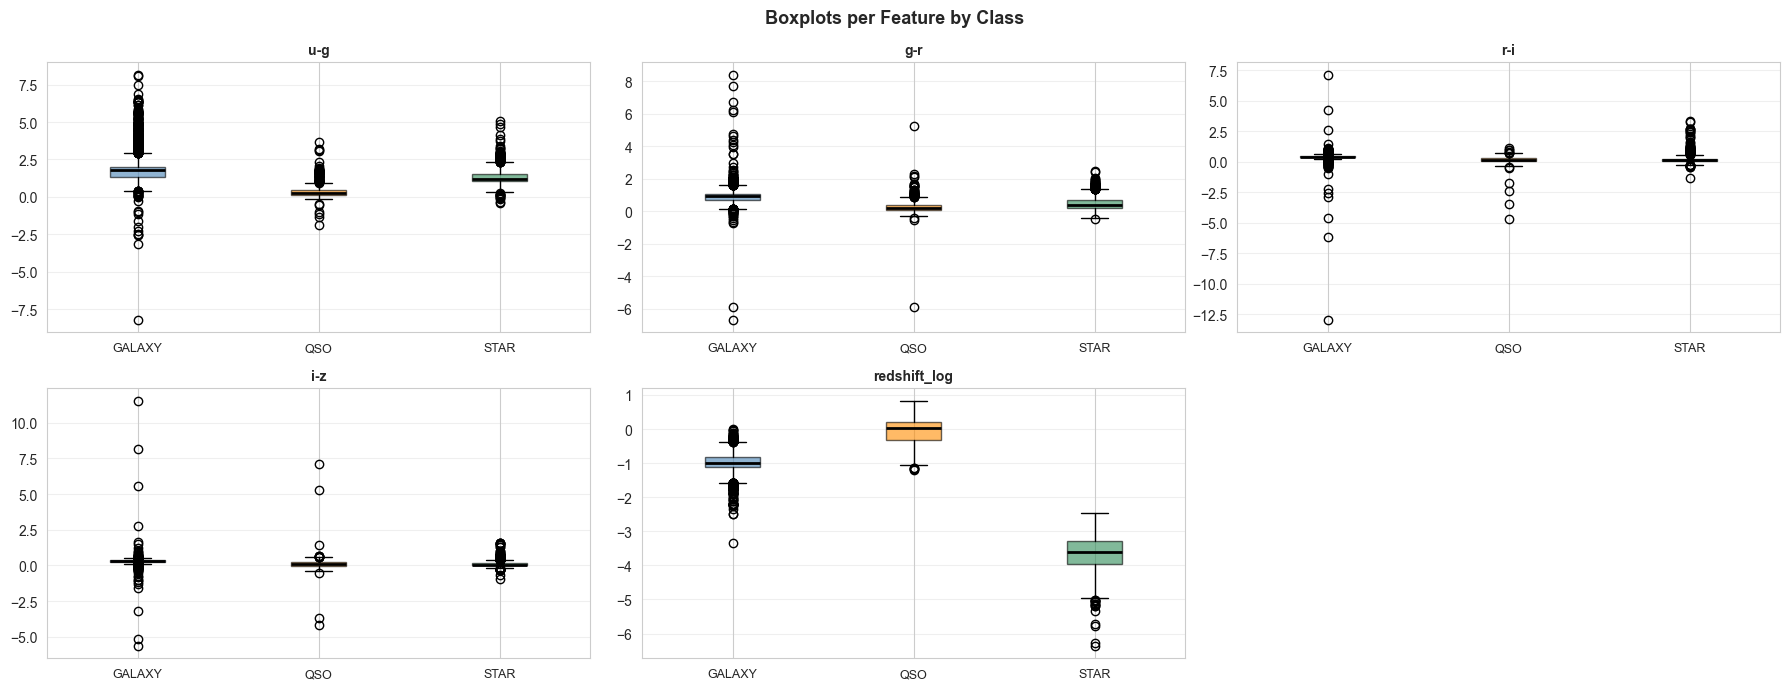

In [12]:
# Boxplots — shows spread, median, and outlier extent per feature
fig, axes = plt.subplots(2, 3, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(feat_cols):
    ax = axes[i]
    data_by_class = [df[df['class'] == cls][col].values
                     for cls in ['GALAXY', 'QSO', 'STAR']]
    bp = ax.boxplot(data_by_class, patch_artist=True, notch=False,
                    medianprops={'color': 'black', 'linewidth': 2})
    for patch, color in zip(bp['boxes'], ['steelblue', 'darkorange', 'seagreen']):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_xticklabels(['GALAXY', 'QSO', 'STAR'], fontsize=9)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

axes[-1].set_visible(False)
plt.suptitle('Boxplots per Feature by Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
from sklearn.preprocessing import RobustScaler, QuantileTransformer
import numpy as np

robust_cols     = ['u-g', 'g-r', 'redshift_log']
quantile_cols   = ['r-i', 'i-z']

X_scaled = np.zeros((len(df), len(feat_cols)))

robust_idx   = [feat_cols.index(c) for c in robust_cols]
quantile_idx = [feat_cols.index(c) for c in quantile_cols]

X_scaled[:, robust_idx] = RobustScaler().fit_transform(df[robust_cols].values)
X_scaled[:, quantile_idx] = QuantileTransformer(
    output_distribution='normal', random_state=42
).fit_transform(df[quantile_cols].values)

### Scaler Selection: Mixed Strategy

| Feature | Scaler | Reason |
|:---|:---|:---|
| `u-g`, `g-r`, `redshift_log` | **RobustScaler** | Moderate skew; outliers present but distribution shape is physically meaningful — median/IQR scaling is sufficient |
| `r-i`, `i-z` | **QuantileTransformer** (normal) | Extreme skewness (\|skew\| > 12) and very high kurtosis (>600) driven by outliers that survive the magnitude filter — mapping to a normal distribution is necessary for distance-based clustering |

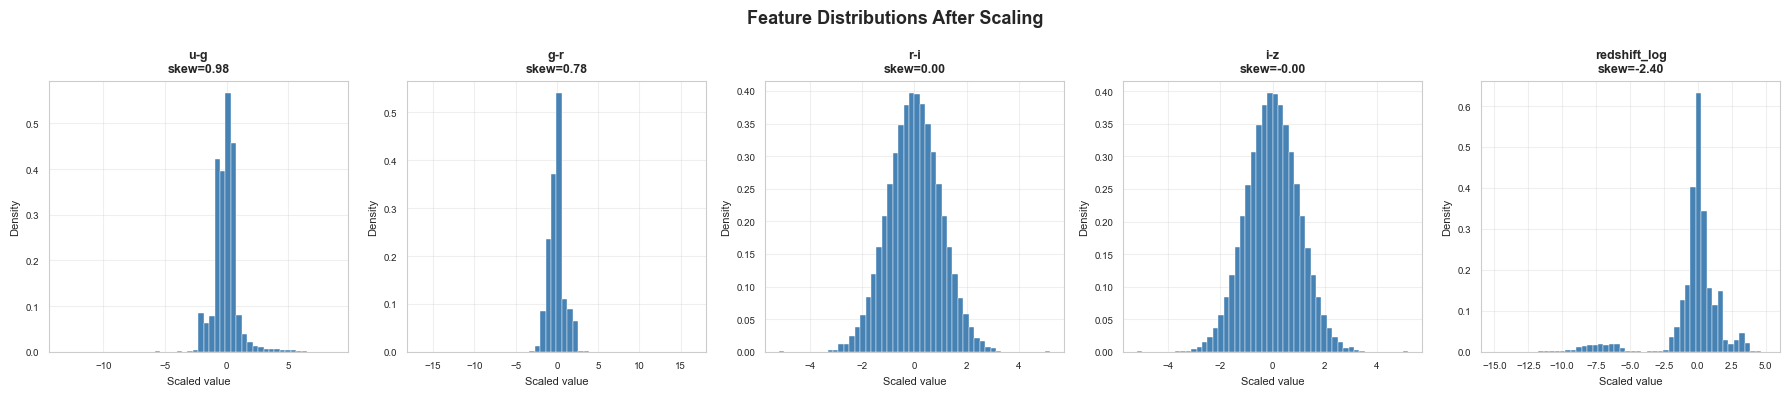

Post-scaling skewness:
u-g             0.9806
g-r             0.7751
r-i             0.0006
i-z            -0.0005
redshift_log   -2.3969


In [14]:
# Distribution check after RobustScaler
fig, axes = plt.subplots(1, len(feat_cols), figsize=(18, 4), sharey=False)

for i, col in enumerate(feat_cols):
    ax = axes[i]
    ax.hist(X_scaled[:, i], bins=50, color='steelblue', edgecolor='white',
            linewidth=0.3, density=True)
    skew = pd.Series(X_scaled[:, i]).skew()
    ax.set_title(f'{col}\nskew={skew:.2f}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Scaled value', fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=7)

plt.suptitle('Feature Distributions After Scaling', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary skew table
scaled_df = pd.DataFrame(X_scaled, columns=feat_cols)
print('Post-scaling skewness:')
print(scaled_df.skew().round(4).to_string())

## 10. Save Dataset

The final dataset contains six colour band differences, log-transformed redshift, and the class label. Saved as `astral_data.csv` for use in downstream clustering models.

In [15]:
df_out = pd.DataFrame(X_scaled, columns=feat_cols)
df_out['class'] = df['class'].values

df_out.to_csv('../Model & Dataset/astral_data.csv', index=False)

print(f'Saved astral_data.csv  (scaled)')
print(f'Shape: {df_out.shape}')
print(f'Columns: {list(df_out.columns)}')
print(f'\nClass distribution:\n{df_out["class"].value_counts().to_string()}')
df_out.head()

Saved astral_data.csv  (scaled)
Shape: (9733, 6)
Columns: ['u-g', 'g-r', 'r-i', 'i-z', 'redshift_log', 'class']

Class distribution:
class
GALAXY    8423
QSO        685
STAR       625


,u-g,g-r,r-i,i-z,redshift_log,class
0,0.282719,0.199441,0.311683,0.203881,-0.145579,GALAXY
1,0.082746,0.183756,1.123312,0.428709,-0.549480,GALAXY
2,-0.312019,-0.067587,-0.128764,0.126954,-0.235675,GALAXY
3,0.397933,0.144873,0.426494,0.523488,-0.196892,GALAXY
4,-0.264895,-0.435012,-0.160010,-0.758546,-0.328149,GALAXY
